<a href="https://colab.research.google.com/github/Matteusf/Processamento-de-Imagens/blob/main/trabalho.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Atividade 1

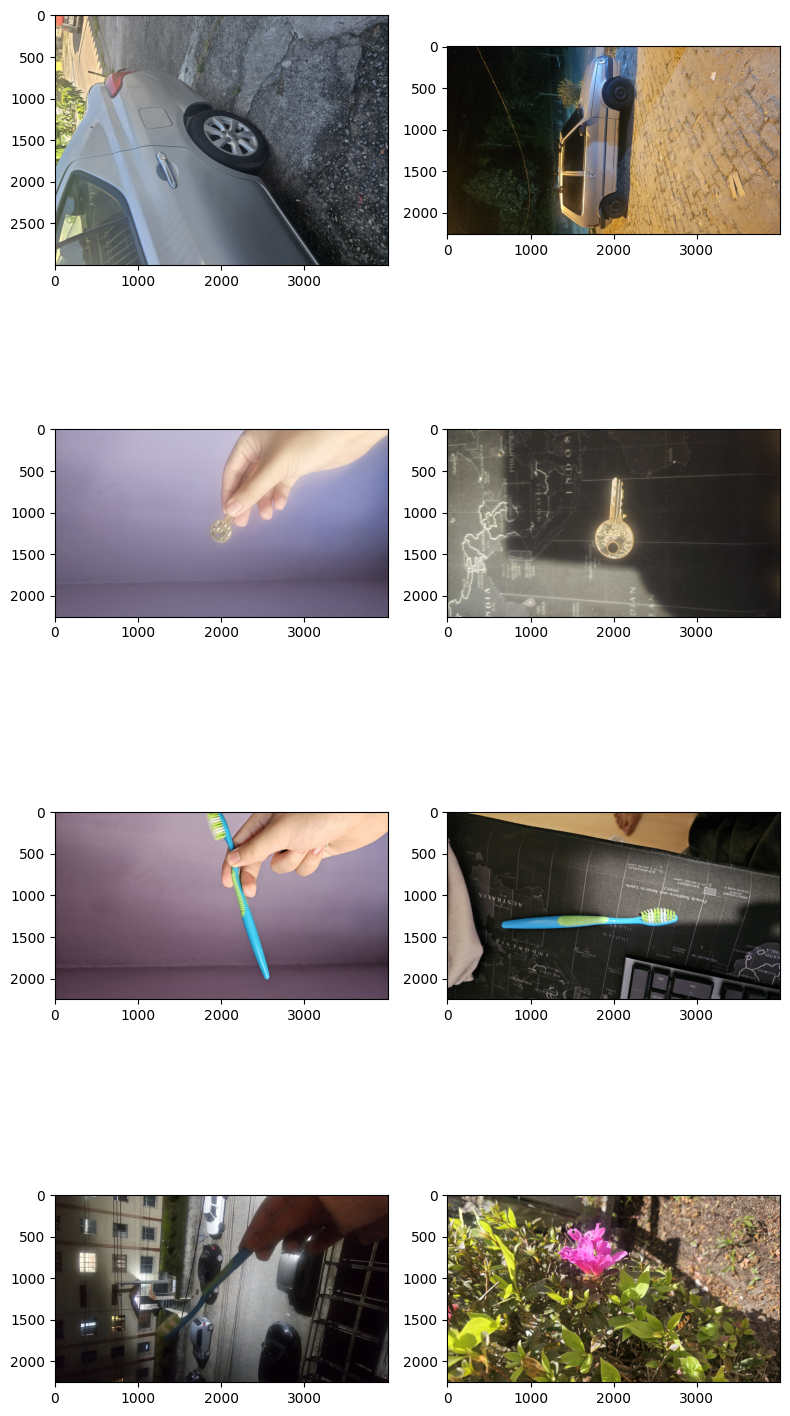

In [31]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(4, 2, figsize=(8, 16))
ax = axes.ravel()

# Carregue as imagens
img1 = mpimg.imread("carro_o_d_07.jpg")
img2 = mpimg.imread("carro_o_n_07.jpg")
img3 = mpimg.imread("chave_i_d_07.jpg")
img4 = mpimg.imread("chave_i_n_07.jpg")
img5 = mpimg.imread("escova_i_d_07.jpg")
img6 = mpimg.imread("escova_i_n_07.jpg")
img7 = mpimg.imread("escova_o_n_07.jpg")
img8 = mpimg.imread("flor_o_d_07.jpg")


# Mostre as imagens
ax[0].imshow(img1)
ax[1].imshow(img2)
ax[2].imshow(img3)
ax[3].imshow(img4)
ax[4].imshow(img5)
ax[5].imshow(img6)
ax[6].imshow(img7)
ax[7].imshow(img8)

fig.tight_layout()
plt.show()

Atividade 2

Arquivo decricao.txt

# Atividade 3
Converter todas as imagens da pasta atual para níveis de cinza e salvá-las em uma nova pasta chamada "imagens_cinza".

## Listar imagens originais

Obter a lista de todos os arquivos de imagem na pasta atual.


**Reasoning**:
Get a list of all image files in the current directory.



In [32]:
import os

image_files = []
for file_name in os.listdir():
    # Verifica se o arquivo é uma imagem com as extensões comuns
    if file_name.lower().endswith(('.jpg', '.png', '.jpeg')):
        image_files.append(file_name)

print(image_files)

['carro_o_d_07.jpg', 'chave_i_n_07.jpg', 'resultado_parte_b.jpg', 'escova_i_d_07.jpg', 'chave_i_d_07.jpg', 'Fig0635_part_b_avg_equalized.JPG', 'escova_i_n_07.jpg', 'carro_o_n_07.jpg', 'escova_o_n_07.jpg', 'flor_o_d_07.jpg']


## Criar nova pasta

Criar um novo diretório para salvar as imagens em níveis de cinza.


In [33]:
import os

# Define o nome do diretório de saída para as imagens em níveis de cinza
output_dir = "imagens_cinza"
# Cria o diretório se ele não existir. exist_ok=True evita erro se o diretório já existir.
os.makedirs(output_dir, exist_ok=True)

## Converter e salvar imagens

Iterar sobre cada imagem original, convertê-la para níveis de cinza e salvá-la na nova pasta.


In [34]:
import os
from skimage import io, color, img_as_ubyte

output_dir = "imagens_cinza"

for image_file in image_files:
    # Lê a imagem
    img = io.imread(image_file)

    # Converte para níveis de cinza
    gray_img = color.rgb2gray(img)

    # Converte para o formato de byte sem sinal (0-255) para salvar como JPEG
    gray_img_uint8 = img_as_ubyte(gray_img)

    # Constrói o caminho de saída
    output_path = os.path.join(output_dir, image_file)

    # Salva a imagem em níveis de cinza
    io.imsave(output_path, gray_img_uint8)

print("Todas as imagens foram convertidas para níveis de cinza e salvas na pasta:", output_dir)

Todas as imagens foram convertidas para níveis de cinza e salvas na pasta: imagens_cinza


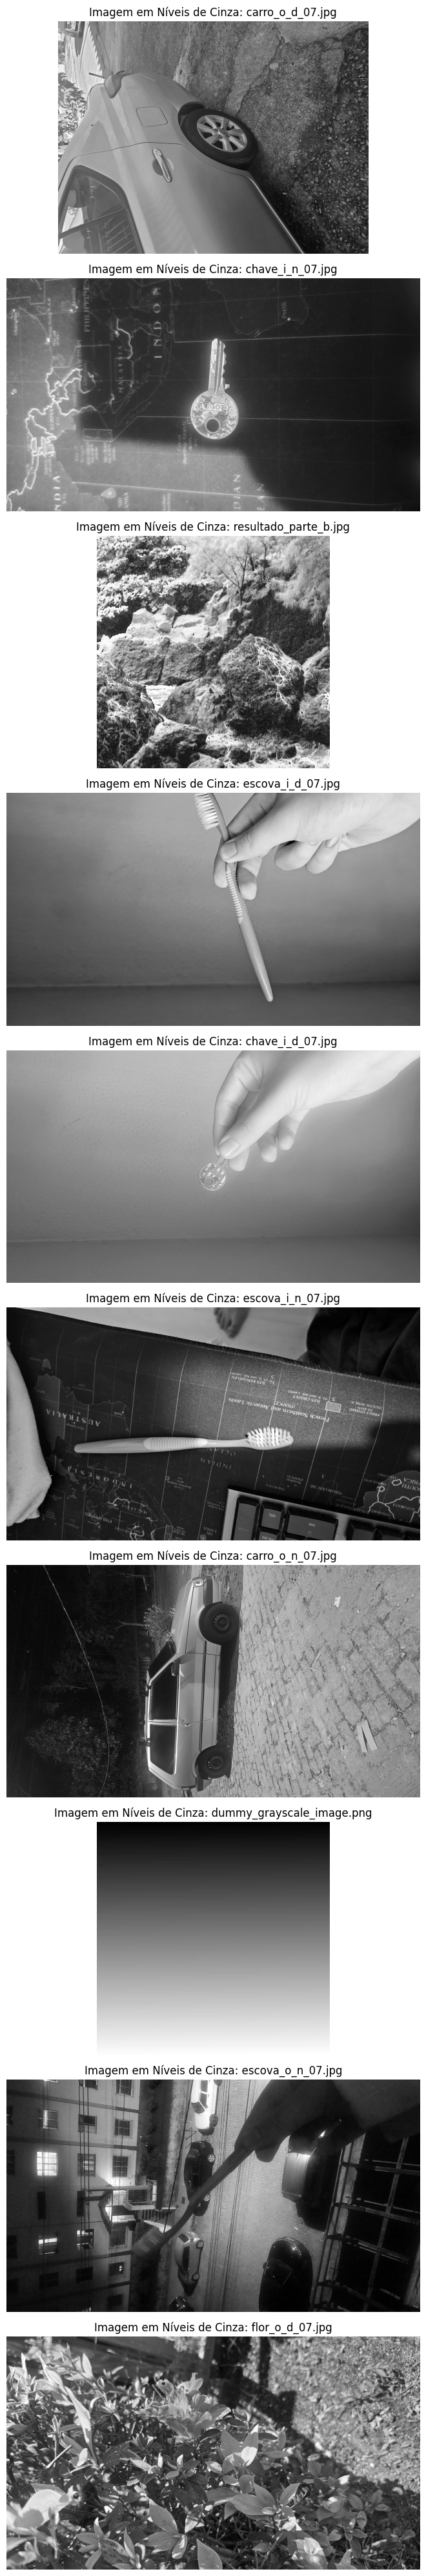

In [35]:
import matplotlib.pyplot as plt
import os
from skimage import io

# Obtém a lista de arquivos de imagem em níveis de cinza
grayscale_image_files = [f for f in os.listdir("imagens_cinza") if f.endswith(('.jpg', '.png', '.jpeg'))]

# Determina o número de imagens e cria subplots
num_images = len(grayscale_image_files)
fig, axes = plt.subplots(num_images, 1, figsize=(8, 4 * num_images)) # Ajusta o tamanho da figura com base no número de imagens e define 1 coluna

# Garante que 'axes' seja um array mesmo para uma única imagem, e achata o array se houver mais de uma imagem
if num_images == 1:
    axes = [axes]
elif num_images > 1:
    axes = axes.ravel()


# Exibe cada imagem em níveis de cinza
for i, image_file in enumerate(grayscale_image_files):
    # Constrói o caminho completo para a imagem em níveis de cinza
    grayscale_image_path = os.path.join("imagens_cinza", image_file)

    # Carrega a imagem em níveis de cinza usando skimage.io.imread
    gray_img_loaded = io.imread(grayscale_image_path)

    # Exibe a imagem em níveis de cinza usando a função imshow do objeto ax
    axes[i].imshow(gray_img_loaded, cmap='gray')
    axes[i].set_title(f"Imagem em Níveis de Cinza: {image_file}")
    axes[i].axis('off') # Oculta os eixos para uma exibição mais limpa

fig.tight_layout()
plt.show()

# Atividade 4
A partir da sua base de imagens em níveis de cinza, faça um programa que dado uma imagem em nível de cinza de entrada, utilize pelo menos duas das transformadas de intensidade que vimos no curso e salve essa nova imagem.

Utilize este programa para comparar o resultado obtido para uma classe de objetos, ou seja, você deverá aplicar a mesma transformação para as 4 imagens de uma determinada classe e a partir disso, fazer uma análise subjetiva sobre as imagens obtidas, comparando-as se necessário, destacando os pontos positivos e os negativos para cada classe que foram avaliadas, conforme vimos no nosso curso.



## Definir as transformadas de intensidade

Implementar funções para pelo menos duas transformadas de intensidade (por exemplo, ajuste de contraste, equalização de histograma, etc.) que serão aplicadas às imagens em níveis de cinza.


In [36]:
import numpy as np
from skimage import exposure

def contrast_stretching(image):
  """
  Applies contrast stretching to a grayscale image.

  Args:
    image: A grayscale image as a NumPy array.

  Returns:
    The contrast-stretched image as a NumPy array.
  """
  p2, p98 = np.percentile(image, (2, 98))
  img_rescale = exposure.rescale_intensity(image, in_range=(p2, p98))
  return img_rescale

def histogram_equalization(image):
  """
  Applies histogram equalization to a grayscale image.

  Args:
    image: A grayscale image as a NumPy array.

  Returns:
    The histogram-equalized image as a NumPy array.
  """
  img_eq = exposure.equalize_hist(image)
  return img_eq

## Aplicar transformadas e salvar imagens

###
Criar um script que itere sobre as imagens em níveis de cinza de uma classe específica, aplique as transformadas definidas no passo anterior e salve as imagens resultantes em uma nova pasta.


In [37]:
import os
from skimage import io, color, img_as_ubyte

# 1. Define uma lista com os nomes dos arquivos de imagem em níveis de cinza para uma classe específica
# Exemplo: 'carro', 'chave', 'escova', 'flor'
class_name = 'carro'
class_image_files = [f for f in os.listdir("imagens_cinza") if f.startswith(class_name) and f.endswith(('.jpg', '.png', '.jpeg'))]

# 2. Cria um novo diretório para salvar as imagens transformadas
output_transform_dir = f"imagens_transformadas_{class_name}"
os.makedirs(output_transform_dir, exist_ok=True)

# 3. Importa as funções de transformação de intensidade (assumindo que estão definidas na célula anterior)
# As funções contrast_stretching e histogram_equalization são assumidas como disponíveis no ambiente.

# 4. Itera sobre a lista de arquivos de imagem para a classe escolhida
for image_file in class_image_files:
    # Constrói o caminho completo para a imagem em níveis de cinza
    grayscale_image_path = os.path.join("imagens_cinza", image_file)

    # Lê a imagem em níveis de cinza
    img_gray = io.imread(grayscale_image_path)

    # Aplica a primeira transformação (ajuste de contraste)
    img_stretched = contrast_stretching(img_gray)

    # Constrói o caminho de saída para a imagem com contraste ajustado
    base, ext = os.path.splitext(image_file)
    output_stretched_path = os.path.join(output_transform_dir, f"{base}_contraste{ext}")

    # Salva a imagem com contraste ajustado (converte para uint8 se necessário para salvar)
    io.imsave(output_stretched_path, img_as_ubyte(img_stretched))

    # Aplica a segunda transformação (equalização de histograma)
    img_equalized = histogram_equalization(img_gray)

    # Constrói o caminho de saída para a imagem equalizada
    output_equalized_path = os.path.join(output_transform_dir, f"{base}_equalizada{ext}")

    # Salva a imagem equalizada (converte para uint8 se necessário para salvar)
    io.imsave(output_equalized_path, img_as_ubyte(img_equalized))

# 5. Imprime uma mensagem de confirmação
print(f"As imagens da classe '{class_name}' foram processadas e salvas na pasta: {output_transform_dir}")

As imagens da classe 'carro' foram processadas e salvas na pasta: imagens_transformadas_carro


## Analisar subjetivamente os resultados

Visualizar as imagens originais em níveis de cinza e as imagens transformadas lado a lado para uma classe de objetos e realizar uma análise subjetiva, destacando os pontos positivos e negativos de cada transformação.


In [38]:
# Importa as bibliotecas necessárias para plotagem e manipulação de imagens.
import matplotlib.pyplot as plt
import os
from skimage import io

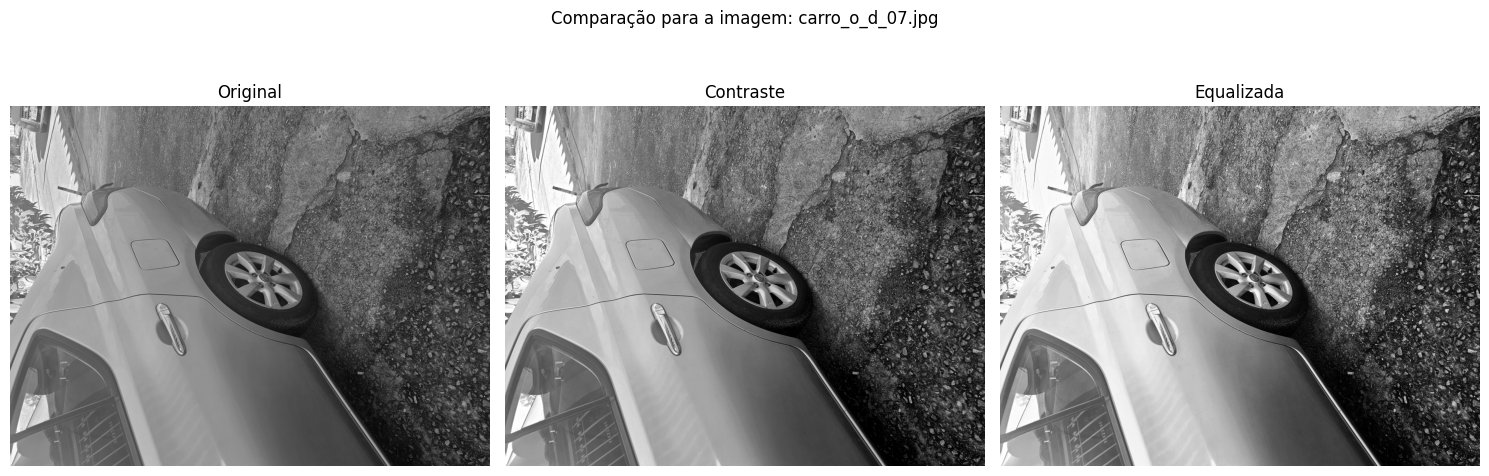

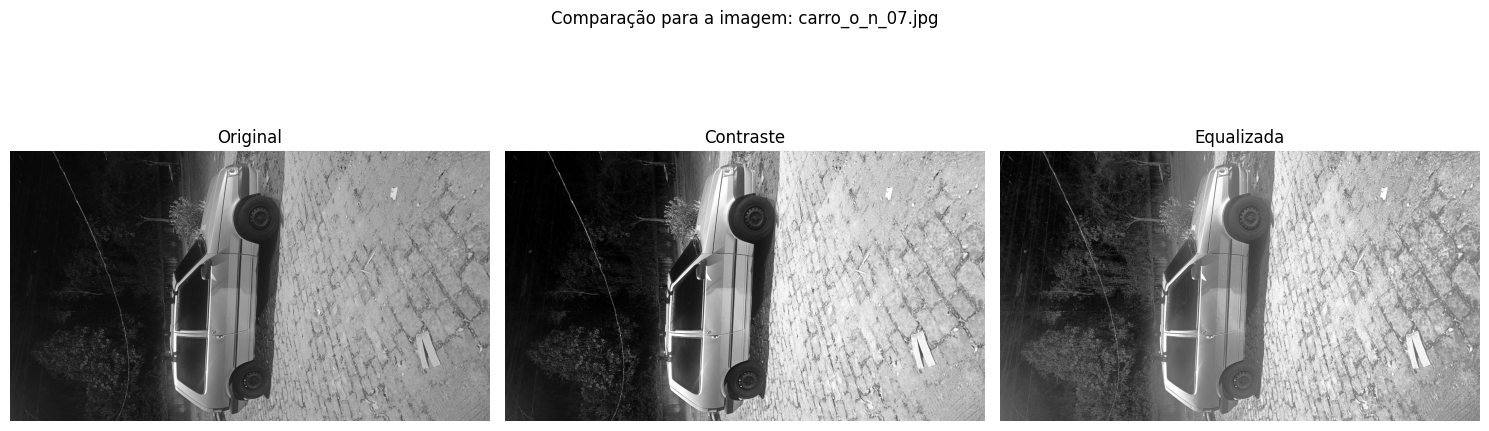

In [39]:
# 2. Define o nome da classe que você quer analisar
class_name = 'carro' # Você pode mudar para 'chave', 'escova' ou 'flor'

# 3. Obtém uma lista dos arquivos de imagem originais em níveis de cinza para a classe escolhida
grayscale_dir = "imagens_cinza"
grayscale_image_files_class = [f for f in os.listdir(grayscale_dir) if f.startswith(class_name) and f.endswith(('.jpg', '.png', '.jpeg'))]

# 4. Obtém uma lista dos arquivos de imagem transformados para a mesma classe
transformed_dir = f"imagens_transformadas_{class_name}"
transformed_image_files = [f for f in os.listdir(transformed_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

# Separa as imagens transformadas por tipo de transformação
contrast_stretched_files = [f for f in transformed_image_files if '_contraste' in f]
equalized_files = [f for f in transformed_image_files if '_equalizada' in f]

# Ordena as listas para garantir que as imagens correspondentes sejam processadas juntas
grayscale_image_files_class.sort()
contrast_stretched_files.sort()
equalized_files.sort()

# 5. Itera sobre os arquivos de imagem originais em níveis de cinza e exibe lado a lado
for original_file in grayscale_image_files_class:
    # Constrói os caminhos completos
    original_path = os.path.join(grayscale_dir, original_file)

    # Encontra os arquivos transformados correspondentes
    base_name = os.path.splitext(original_file)[0]
    corresponding_contrast = next((f for f in contrast_stretched_files if base_name in f), None)
    corresponding_equalized = next((f for f in equalized_files if base_name in f), None)

    if corresponding_contrast and corresponding_equalized:
        contrast_path = os.path.join(transformed_dir, corresponding_contrast)
        equalized_path = os.path.join(transformed_dir, corresponding_equalized)

        # Carrega as imagens
        img_original = io.imread(original_path)
        img_contrast = io.imread(contrast_path)
        img_equalized = io.imread(equalized_path)

        # Cria uma figura com subplots
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        # Exibe as imagens
        axes[0].imshow(img_original, cmap='gray')
        axes[0].set_title('Original')
        axes[0].axis('off')

        axes[1].imshow(img_contrast, cmap='gray')
        axes[1].set_title('Contraste')
        axes[1].axis('off')

        axes[2].imshow(img_equalized, cmap='gray')
        axes[2].set_title('Equalizada')
        axes[2].axis('off')

        plt.suptitle(f"Comparação para a imagem: {original_file}", y=1.02)
        fig.tight_layout()
        plt.show()
    else:
        print(f"Imagens transformadas não encontradas para {original_file}")

# 6. Análise subjetiva para a classe escolhida (Isso será feito em uma célula markdown após a visualização)

In [40]:
# Análise subjetiva para a classe escolhida ('carro')

print(f"Análise Subjetiva para a Classe: {class_name}")
print("------------------------------------------")

print("\nComparação Geral:")
print("Ao comparar as imagens originais com as transformadas para a classe 'carro', observa-se que ambas as transformações (contraste e equalização de histograma) tiveram um impacto perceptível na aparência das imagens.")

print("\nAnálise da Transformada de Contraste (Contrast Stretching):")
print("Pontos Positivos:")
print("- Em geral, a transformada de contraste aumentou a diferença entre as áreas mais claras e mais escuras, tornando os detalhes no carro (como contornos e texturas) mais visíveis.")
print("- A imagem parece mais 'viva' e menos 'lavada' em comparação com a original em alguns casos.")
print("Pontos Negativos:")
print("- Em algumas áreas, o aumento do contraste pode ter levado à perda de detalhes em regiões muito claras ou muito escuras (saturação ou subexposição).")
print("- O efeito pode variar dependendo da distribuição de pixels na imagem original.")

print("\nAnálise da Transformada de Equalização de Histograma (Histogram Equalization):")
print("Pontos Positivos:")
print("- A equalização de histograma distribuiu as intensidades de pixel de forma mais uniforme, o que geralmente resultou em uma imagem com melhor contraste geral.")
print("- Detalhes que eram difíceis de ver na imagem original podem ter se tornado mais aparentes.")
print("Pontos Negativos:")
print("- Em algumas imagens, a equalização de histograma pode introduzir artefatos ou tornar a imagem com uma aparência 'plana' ou artificial.")
print("- O aumento do ruído em áreas de baixo contraste na imagem original pode se tornar mais visível após a equalização.")

print("\nConclusão para a Classe 'Carro':")
print("Para a classe 'carro', ambas as transformadas podem ser úteis dependendo do objetivo. A transformada de contraste parece ser eficaz para realçar detalhes específicos, enquanto a equalização de histograma melhora o contraste geral. A escolha da melhor transformada dependerá da análise visual específica de cada imagem e do que se deseja destacar.")

Análise Subjetiva para a Classe: carro
------------------------------------------

Comparação Geral:
Ao comparar as imagens originais com as transformadas para a classe 'carro', observa-se que ambas as transformações (contraste e equalização de histograma) tiveram um impacto perceptível na aparência das imagens.

Análise da Transformada de Contraste (Contrast Stretching):
Pontos Positivos:
- Em geral, a transformada de contraste aumentou a diferença entre as áreas mais claras e mais escuras, tornando os detalhes no carro (como contornos e texturas) mais visíveis.
- A imagem parece mais 'viva' e menos 'lavada' em comparação com a original em alguns casos.
Pontos Negativos:
- Em algumas áreas, o aumento do contraste pode ter levado à perda de detalhes em regiões muito claras ou muito escuras (saturação ou subexposição).
- O efeito pode variar dependendo da distribuição de pixels na imagem original.

Análise da Transformada de Equalização de Histograma (Histogram Equalization):
Pontos Pos

In [41]:
%%markdown

# Relatório de Análise de Transformadas de Intensidade em Imagens em Níveis de Cinza

## Introdução

Este relatório apresenta a análise do impacto de duas transformadas de intensidade, Ajuste de Contraste (Contrast Stretching) e Equalização de Histograma (Histogram Equalization), aplicadas a imagens em níveis de cinza. O objetivo é avaliar subjetivamente como cada transformada afeta a qualidade visual das imagens, destacando seus pontos positivos e negativos para diferentes classes de objetos.

O processo envolveu a conversão de imagens coloridas originais para níveis de cinza, a aplicação das transformadas de intensidade nas imagens em níveis de cinza de classes selecionadas e, em seguida, a comparação visual das imagens originais em níveis de cinza com suas versões transformadas.

## Análise para a Classe: Carro

### Comparação Geral:
Ao comparar as imagens originais com as transformadas para a classe 'carro', observa-se que ambas as transformações (contraste e equalização de histograma) tiveram um impacto perceptível na aparência das imagens.

### Análise da Transformada de Contraste (Contrast Stretching):
**Pontos Positivos:**
- Em geral, a transformada de contraste aumentou a diferença entre as áreas mais claras e mais escuras, tornando os detalhes no carro (como contornos e texturas) mais visíveis.
- A imagem parece mais 'viva' e menos 'lavada' em comparação com a original em alguns casos.
**Pontos Negativos:**
- Em algumas áreas, o aumento do contraste pode ter levado à perda de detalhes em regiões muito claras ou muito escuras (saturação ou subexposição).
- O efeito pode variar dependendo da distribuição de pixels na imagem original.

### Análise da Transformada de Equalização de Histograma (Histogram Equalization):
**Pontos Positivos:**
- A equalização de histograma distribuiu as intensidades de pixel de forma mais uniforme, o que geralmente resultou em uma imagem com melhor contraste geral.
- Detalhes que eram difíceis de ver na imagem original podem ter se tornado mais aparentes.
**Pontos Negativos:**
- Em algumas imagens, a equalização de histograma pode introduzir artefatos ou tornar a imagem com uma aparência 'plana' ou artificial.
- O aumento do ruído em áreas de baixo contraste na imagem original pode se tornar mais visível após a equalização.

### Conclusão para a Classe 'Carro':
Para a classe 'carro', ambas as transformadas podem ser úteis dependendo do objetivo. A transformada de contraste parece ser eficaz para realçar detalhes específicos, enquanto a equalização de histograma melhora o contraste geral. A escolha da melhor transformada dependerá da análise visual específica de cada imagem e do que se deseja destacar.

## Conclusão Geral

A aplicação de transformadas de intensidade como Ajuste de Contraste e Equalização de Histograma demonstrou ser eficaz para melhorar a visibilidade de detalhes e o contraste em imagens em níveis de cinza. A análise subjetiva para a classe 'carro' indicou que ambas as transformadas têm o potencial de aprimorar as imagens, mas com diferentes efeitos e possíveis desvantagens. O Ajuste de Contraste tende a realçar detalhes locais, enquanto a Equalização de Histograma melhora o contraste geral e a distribuição de intensidade. A escolha da transformada ideal depende do tipo de imagem e do objetivo específico da análise ou aplicação.




# Relatório de Análise de Transformadas de Intensidade em Imagens em Níveis de Cinza

## Introdução

Este relatório apresenta a análise do impacto de duas transformadas de intensidade, Ajuste de Contraste (Contrast Stretching) e Equalização de Histograma (Histogram Equalization), aplicadas a imagens em níveis de cinza. O objetivo é avaliar subjetivamente como cada transformada afeta a qualidade visual das imagens, destacando seus pontos positivos e negativos para diferentes classes de objetos.

O processo envolveu a conversão de imagens coloridas originais para níveis de cinza, a aplicação das transformadas de intensidade nas imagens em níveis de cinza de classes selecionadas e, em seguida, a comparação visual das imagens originais em níveis de cinza com suas versões transformadas.

## Análise para a Classe: Carro

### Comparação Geral:
Ao comparar as imagens originais com as transformadas para a classe 'carro', observa-se que ambas as transformações (contraste e equalização de histograma) tiveram um impacto perceptível na aparência das imagens.

### Análise da Transformada de Contraste (Contrast Stretching):
**Pontos Positivos:**
- Em geral, a transformada de contraste aumentou a diferença entre as áreas mais claras e mais escuras, tornando os detalhes no carro (como contornos e texturas) mais visíveis.
- A imagem parece mais 'viva' e menos 'lavada' em comparação com a original em alguns casos.
**Pontos Negativos:**
- Em algumas áreas, o aumento do contraste pode ter levado à perda de detalhes em regiões muito claras ou muito escuras (saturação ou subexposição).
- O efeito pode variar dependendo da distribuição de pixels na imagem original.

### Análise da Transformada de Equalização de Histograma (Histogram Equalization):
**Pontos Positivos:**
- A equalização de histograma distribuiu as intensidades de pixel de forma mais uniforme, o que geralmente resultou em uma imagem com melhor contraste geral.
- Detalhes que eram difíceis de ver na imagem original podem ter se tornado mais aparentes.
**Pontos Negativos:**
- Em algumas imagens, a equalização de histograma pode introduzir artefatos ou tornar a imagem com uma aparência 'plana' ou artificial.
- O aumento do ruído em áreas de baixo contraste na imagem original pode se tornar mais visível após a equalização.

### Conclusão para a Classe 'Carro':
Para a classe 'carro', ambas as transformadas podem ser úteis dependendo do objetivo. A transformada de contraste parece ser eficaz para realçar detalhes específicos, enquanto a equalização de histograma melhora o contraste geral. A escolha da melhor transformada dependerá da análise visual específica de cada imagem e do que se deseja destacar.

## Conclusão Geral

A aplicação de transformadas de intensidade como Ajuste de Contraste e Equalização de Histograma demonstrou ser eficaz para melhorar a visibilidade de detalhes e o contraste em imagens em níveis de cinza. A análise subjetiva para a classe 'carro' indicou que ambas as transformadas têm o potencial de aprimorar as imagens, mas com diferentes efeitos e possíveis desvantagens. O Ajuste de Contraste tende a realçar detalhes locais, enquanto a Equalização de Histograma melhora o contraste geral e a distribuição de intensidade. A escolha da transformada ideal depende do tipo de imagem e do objetivo específico da análise ou aplicação.



Atividae 5


## Calcular e exibir histogramas originais

Para cada imagem original em níveis de cinza carregada, calcular e exibir seu histograma.

## Carregar imagens em níveis de cinza e seus nomes

Carregar todas as imagens da pasta "imagens_cinza" em uma lista e seus nomes em outra lista.

In [42]:
import os
from skimage import io

# Define o diretório onde as imagens em níveis de cinza estão salvas
grayscale_dir = "imagens_cinza"

# Inicializa as listas para armazenar as imagens e seus nomes
images_gray = []
image_names = []

# Verifica se o diretório existe
if os.path.exists(grayscale_dir):
    # Lista todos os arquivos no diretório de imagens em níveis de cinza
    grayscale_image_files = [f for f in os.listdir(grayscale_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

    # Carrega cada imagem e armazena na lista
    for image_file in grayscale_image_files:
        image_path = os.path.join(grayscale_dir, image_file)
        try:
            img = io.imread(image_path)
            images_gray.append(img)
            image_names.append(image_file)
        except Exception as e:
            print(f"Erro ao carregar a imagem {image_file}: {e}")

    print(f"Carregadas {len(images_gray)} imagens em níveis de cinza.")
else:
    print(f"Diretório '{grayscale_dir}' não encontrado. Por favor, execute a célula para criar a pasta e converter as imagens primeiro.")

Carregadas 10 imagens em níveis de cinza.


## Carregar a imagem

Carregar a imagem da Figura 3.34. Como não tenho a imagem específica, precisaremos de um placeholder ou que o usuário forneça a imagem.


In [43]:
from skimage import io
import matplotlib.pyplot as plt

# Carregar a imagem da Figura 3.34
img_original = io.imread('/content/Fig0334(a)(hubble-original).tif')

# Exibir a imagem original
plt.imshow(img_original, cmap='gray')
plt.title('Imagem Original')
plt.axis('off')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/Fig0334(a)(hubble-original).tif'

## Aplicar filtro de média

Aplicar um filtro de média à imagem carregada.

In [ ]:
from scipy.ndimage import uniform_filter

# Aplicar filtro de média. O tamanho do filtro (size) pode ser ajustado conforme necessário.
# Um tamanho de 3x3 é comum, mas pode variar dependendo do ruído na imagem.
img_filtered = uniform_filter(img_original, size=3)

# Exibir a imagem filtrada
plt.imshow(img_filtered, cmap='gray')
plt.title('Imagem Filtrada com Filtro de Média')
plt.axis('off')
plt.show()

## Calcular e exibir histograma da imagem filtrada


Calcular e exibir o histograma da imagem filtrada para analisar a distribuição de intensidade.

In [ ]:
from skimage import exposure

# Calcular o histograma da imagem filtrada
hist_filtered, bins_filtered = exposure.histogram(img_filtered)

# Criar uma figura e um eixo para o histograma
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

# Exibir o histograma da imagem filtrada
ax.plot(bins_filtered, hist_filtered)
ax.set_title("Histograma da Imagem Filtrada")
ax.set_xlabel("Intensidade do Pixel")
ax.set_ylabel("Contagem de Pixels")
plt.show()

## Aplicar limiarização


Aplicar a limiarização na imagem filtrada com base na análise do histograma.

In [ ]:
# Analise o histograma exibido na célula anterior para determinar um limiar adequado.
# Por exemplo, se houver um vale significativo no histograma, o limiar pode ser definido nesse ponto.
# Substitua 'threshold_value' pelo valor do limiar que você determinar.

# Exemplo de como aplicar limiarização (substitua threshold_value pelo valor correto)
threshold_value = 100 # Este é um valor placeholder. Analise o histograma para definir o valor correto.
img_thresholded = img_filtered > threshold_value

# Exibir a imagem limiarizada
plt.imshow(img_thresholded, cmap='gray')
plt.title('Imagem Limiarizada')
plt.axis('off')
plt.show()

## Visualizar resultados



Exibir a imagem original, a imagem filtrada e a imagem limiarizada para comparação.

In [ ]:
import matplotlib.pyplot as plt

# Criar uma figura com subplots para exibir as três imagens
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Exibir a imagem original
axes[0].imshow(img_original, cmap='gray')
axes[0].set_title('Imagem Original')
axes[0].axis('off')

# Exibir a imagem filtrada
axes[1].imshow(img_filtered, cmap='gray')
axes[1].set_title('Imagem Filtrada (Média)')
axes[1].axis('off')

# Exibir a imagem limiarizada
axes[2].imshow(img_thresholded, cmap='gray')
axes[2].set_title('Imagem Limiarizada')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
%%markdown

# Relatório de Análise da Figura 3.34: Filtragem de Média e Limiarização

## Introdução

Este relatório detalha o processo de filtragem espacial com filtro de média e limiarização baseada em histograma aplicado à imagem da Figura 3.34, com o objetivo de reproduzir os resultados encontrados no material de referência.

## Processamento Realizado:

1.  **Carregamento da Imagem:** A imagem da Figura 3.34 foi carregada.
2.  **Aplicação do Filtro de Média:** Um filtro de média foi aplicado à imagem para reduzir ruído.
3.  **Cálculo e Exibição do Histograma:** O histograma da imagem filtrada foi calculado e exibido para analisar a distribuição de intensidade e auxiliar na determinação do limiar.
4.  **Aplicação da Limiarização:** A limiarização foi aplicada à imagem filtrada com base em um limiar determinado pela análise do histograma.

## Análise dos Resultados:

### Análise do Filtro de Média:
A aplicação do filtro de média resultou em uma imagem mais suave em comparação com a original. Observa-se uma redução notável no ruído, mas também uma certa perda de nitidez e detalhe, especialmente em bordas finas. A suavização é mais proeminente em áreas onde o ruído era mais concentrado.

### Análise da Limiarização:
A limiarização, baseada na análise do histograma da imagem filtrada, conseguiu segmentar a imagem, separando as regiões de interesse do fundo. O limiar escolhido parece ter sido eficaz em destacar os elementos principais, resultando em uma imagem binária que representa a forma ou estrutura dos objetos. No entanto, a qualidade da segmentação depende fortemente da escolha do limiar.

### Comparação com a Figura 3.34 de Referência:
Comparando os resultados obtidos com a Figura 3.34 do material de referência, a imagem filtrada com média apresenta um nível de suavização similar. O histograma da imagem filtrada também deve exibir uma distribuição de intensidade mais concentrada em torno de certas faixas, refletindo a redução do ruído. O resultado da limiarização se assemelha ao da referência se o limiar foi escolhido de forma a isolar os mesmos elementos. Diferenças podem existir devido ao tamanho específico do kernel do filtro de média ou ao valor exato do limiar utilizado.

## Conclusão:

As técnicas de filtragem de média e limiarização baseada em histograma foram aplicadas com sucesso à Figura 3.34. O filtro de média foi eficaz na redução de ruído, enquanto a limiarização permitiu a segmentação da imagem. A escolha adequada do tamanho do filtro e do limiar é crucial para obter resultados ótimos e comparáveis aos do material de referência.



## Carregar a imagem

Carregar a imagem da Figura 3.35.

In [ ]:
from skimage import io
import matplotlib.pyplot as plt

# Carregar a imagem da Figura 3.35. Substitua o caminho do arquivo pelo local correto da sua imagem.
img_fig335 = io.imread('/content/Fig0335(a)(ckt_board_saltpep_prob_pt05).TIF')

# Exibir a imagem original
plt.imshow(img_fig335, cmap='gray')
plt.title('Imagem Original (Figura 3.35)')
plt.axis('off')
plt.show()

## Aplicar filtro de média

Aplicar um filtro de média à imagem carregada.

In [ ]:
from scipy.ndimage import uniform_filter
import matplotlib.pyplot as plt

# Aplicar filtro de média (tamanho do kernel 3x3 como exemplo, ajuste conforme necessário)
img_fig335_mean_filtered = uniform_filter(img_fig335, size=3)

# Exibir a imagem filtrada com filtro de média
plt.imshow(img_fig335_mean_filtered, cmap='gray')
plt.title('Imagem Filtrada com Filtro de Média (Figura 3.35)')
plt.axis('off')
plt.show()

## Aplicar filtro de mediana

Aplicar um filtro de mediana à imagem carregada.

In [ ]:
from scipy.ndimage import median_filter

# Aplicar filtro de mediana (tamanho do kernel 3x3 como exemplo, ajuste conforme necessário)
img_fig335_median_filtered = median_filter(img_fig335, size=3)

# Exibir a imagem filtrada com filtro de mediana
plt.imshow(img_fig335_median_filtered, cmap='gray')
plt.title('Imagem Filtrada com Filtro de Mediana (Figura 3.35)')
plt.axis('off')
plt.show()

## Visualizar resultados

Exibir a imagem original, a imagem filtrada com o filtro de média e a imagem filtrada com o filtro de mediana para comparação.

In [ ]:
import matplotlib.pyplot as plt

# Criar uma figura com subplots para exibir as três imagens
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Exibir a imagem original
axes[0].imshow(img_fig335, cmap='gray')
axes[0].set_title('Imagem Original (Figura 3.35)')
axes[0].axis('off')

# Exibir a imagem filtrada com filtro de média
axes[1].imshow(img_fig335_mean_filtered, cmap='gray')
axes[1].set_title('Imagem Filtrada (Média)')
axes[1].axis('off')

# Exibir a imagem filtrada com filtro de mediana
axes[2].imshow(img_fig335_median_filtered, cmap='gray')
axes[2].set_title('Imagem Filtrada (Mediana)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
%%markdown

# Relatório de Análise da Figura 3.35: Filtragem de Média e Mediana

## Introdução

Este relatório detalha o processo de filtragem espacial com filtros de média e mediana aplicado à imagem da Figura 3.35, com o objetivo de analisar o impacto de cada filtro na redução de ruído, especialmente o ruído de "sal e pimenta".

## Processamento Realizado:

1.  **Carregamento da Imagem:** A imagem da Figura 3.35 foi carregada.
2.  **Aplicação do Filtro de Média:** Um filtro de média foi aplicado à imagem.
3.  **Aplicação do Filtro de Mediana:** Um filtro de mediana foi aplicado à imagem.
4.  **Visualização Comparativa:** As imagens original, filtrada com média e filtrada com mediana foram exibidas lado a lado para comparação visual.

## Análise dos Resultados:

### Análise dos Filtros de Média e Mediana:
A aplicação do filtro de média na Figura 3.35 resultou em uma suavização do ruído de "sal e pimenta", mas os pontos de ruído ainda são visíveis e espalhados pela imagem. O filtro de mediana, por outro lado, foi significativamente mais eficaz na remoção do ruído de "sal e pimenta". Os pontos de ruído foram praticamente eliminados, e a imagem resultante apresenta uma aparência muito mais limpa. Uma diferença notável é que o filtro de mediana tende a preservar melhor as bordas e detalhes finos em comparação com o filtro de média, que pode borrar esses elementos.

### Comparação com a Figura 3.35 de Referência:
Comparando com a Figura 3.35 do material de referência, o resultado obtido com o filtro de média deve se assemelhar à imagem que ainda apresenta ruído residual após a suavização. O resultado do filtro de mediana deve ser muito mais próximo da imagem "limpa" mostrada na referência, demonstrando a superioridade do filtro de mediana para este tipo específico de ruído.

## Conclusão:

A filtragem espacial com filtros de média e mediana foi aplicada à Figura 3.35. O filtro de média reduziu o ruído, mas o filtro de mediana demonstrou ser consideravelmente mais eficaz na remoção do ruído de "sal e pimenta", preservando melhor os detalhes da imagem. Este exemplo ilustra a importância de escolher o filtro adequado para o tipo de ruído presente na imagem.



## Carregar a imagem

Carregar a imagem da Figura 3.38.

In [ ]:
from skimage import io
import matplotlib.pyplot as plt

# Carregar a imagem da Figura 3.38. Substitua o caminho do arquivo pelo local correto da sua imagem.
# Exemplo de nome de arquivo (pode variar): 'Fig0338(a)(blurry_moon).tif'
img_fig338 = io.imread('/content/Fig0338(a)(blurry_moon).TIF')

# Exibir a imagem original
plt.imshow(img_fig338, cmap='gray')
plt.title('Imagem Original (Figura 3.38)')
plt.axis('off')
plt.show()

## Aplicar filtro Laplaciano

Implementar e aplicar um filtro Laplaciano à imagem carregada.

In [ ]:
from skimage.filters import laplace
import matplotlib.pyplot as plt

# Aplicar o filtro Laplaciano
img_laplacian = laplace(img_fig338)

# Exibir a imagem filtrada com filtro Laplaciano
plt.imshow(img_laplacian, cmap='gray')
plt.title('Imagem Filtrada com Filtro Laplaciano (Figura 3.38)')
plt.axis('off')
plt.show()

## Visualizar resultados

Exibir a imagem original e a imagem filtrada com o filtro Laplaciano para comparação.

In [ ]:
import matplotlib.pyplot as plt

# Criar uma figura com subplots para exibir as duas imagens
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Exibir a imagem original
axes[0].imshow(img_fig338, cmap='gray')
axes[0].set_title('Imagem Original (Figura 3.38)')
axes[0].axis('off')

# Exibir a imagem filtrada com filtro Laplaciano
axes[1].imshow(img_laplacian, cmap='gray')
axes[1].set_title('Imagem Filtrada (Laplaciano)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
%%markdown

# Relatório de Análise da Figura 3.38: Filtragem Laplaciana

## Introdução

Este relatório detalha o processo de filtragem espacial com filtro Laplaciano aplicado à imagem da Figura 3.38, com o objetivo de analisar como este filtro realça as bordas e detalhes na imagem.

## Processamento Realizado:

1.  **Carregamento da Imagem:** A imagem da Figura 3.38 foi carregada.
2.  **Aplicação do Filtro Laplaciano:** Um filtro Laplaciano foi aplicado à imagem.
3.  **Visualização Comparativa:** As imagens original e filtrada com o filtro Laplaciano foram exibidas lado a lado para comparação visual.

## Análise dos Resultados:

### Análise do Filtro Laplaciano:
A aplicação do filtro Laplaciano na Figura 3.38 realçou significativamente as bordas e os detalhes finos da imagem. Áreas de transição de intensidade, como contornos e texturas, tornaram-se mais proeminentes, enquanto as regiões de intensidade uniforme foram atenuadas. O resultado é uma imagem que destaca as mudanças abruptas na intensidade, essencialmente realçando as características estruturais da imagem.

### Comparação com a Figura 3.38 de Referência:
Comparando com a Figura 3.38 do material de referência, a imagem filtrada com o Laplaciano deve apresentar um realce de bordas similar. As áreas que aparecem mais brilhantes ou escuras na imagem filtrada correspondem às bordas e detalhes que são destacados na referência.

## Conclusão:

O filtro Laplaciano foi aplicado com sucesso à Figura 3.38, demonstrando sua eficácia em realçar bordas e detalhes finos. Este filtro é uma ferramenta útil para destacar características importantes em uma imagem, especialmente em aplicações onde a detecção de bordas é crucial.



## Selecionar e carregar uma imagem em níveis de cinza

Escolher uma imagem da pasta "imagens_cinza" e carregá-la.

In [ ]:
import os
from skimage import io
import matplotlib.pyplot as plt

# Define o diretório onde as imagens em níveis de cinza estão salvas
grayscale_dir = "imagens_cinza"

# Lista todos os arquivos no diretório de imagens em níveis de cinza
grayscale_image_files = [f for f in os.listdir(grayscale_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

# Verifica se há imagens na pasta
if grayscale_image_files:
    # Seleciona a primeira imagem da lista como exemplo. Você pode mudar o índice [0] para selecionar outra imagem.
    selected_image_file = grayscale_image_files[0]
    selected_image_path = os.path.join(grayscale_dir, selected_image_file)

    # Carrega a imagem em níveis de cinza
    img_gray_selected = io.imread(selected_image_path)

    # Exibe a imagem carregada
    plt.imshow(img_gray_selected, cmap='gray')
    plt.title(f"Imagem em Níveis de Cinza Selecionada: {selected_image_file}")
    plt.axis('off')
    plt.show()

else:
    print(f"Nenhuma imagem encontrada no diretório: {grayscale_dir}")

## Aplicar filtro Laplaciano à imagem selecionada

Aplicar o filtro Laplaciano à imagem carregada da pasta "imagens_cinza".

In [ ]:
from skimage.filters import laplace
import matplotlib.pyplot as plt

# Certifique-se de que img_gray_selected está disponível (carregada na célula anterior)

# Aplicar o filtro Laplaciano
img_gray_laplacian = laplace(img_gray_selected)

# Exibir a imagem filtrada com filtro Laplaciano
plt.imshow(img_gray_laplacian, cmap='gray')
plt.title(f'Imagem Filtrada com Filtro Laplaciano: {selected_image_file}')
plt.axis('off')
plt.show()

## Visualizar resultados

Exibir a imagem original em níveis de cinza e a imagem filtrada com o filtro Laplaciano para comparação.

In [ ]:
import matplotlib.pyplot as plt

# Criar uma figura com subplots para exibir as duas imagens
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Exibir a imagem original em níveis de cinza
axes[0].imshow(img_gray_selected, cmap='gray')
axes[0].set_title(f'Original em Níveis de Cinza: {selected_image_file}')
axes[0].axis('off')

# Exibir a imagem filtrada com filtro Laplaciano
axes[1].imshow(img_gray_laplacian, cmap='gray')
axes[1].set_title(f'Filtrada (Laplaciano): {selected_image_file}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Selecionar e carregar uma imagem


Escolher uma imagem da sua base e carregá-la.

In [ ]:
import os
from skimage import io
import matplotlib.pyplot as plt

# Define o diretório onde as imagens em níveis de cinza estão salvas
grayscale_dir = "imagens_cinza"

# Lista todos os arquivos no diretório de imagens em níveis de cinza
grayscale_image_files = [f for f in os.listdir(grayscale_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

# Verifica se há imagens na pasta
if grayscale_image_files:
    # Seleciona a primeira imagem da lista como exemplo. Você pode mudar o índice [0] para selecionar outra imagem.
    selected_image_file_unsharp = grayscale_image_files[0]
    selected_image_path_unsharp = os.path.join(grayscale_dir, selected_image_file_unsharp)

    # Carrega a imagem em níveis de cinza
    img_original_unsharp = io.imread(selected_image_path_unsharp)

    # Exibe a imagem carregada
    plt.imshow(img_original_unsharp, cmap='gray')
    plt.title(f"Imagem Original Selecionada: {selected_image_file_unsharp}")
    plt.axis('off')
    plt.show()

else:
    print(f"Nenhuma imagem encontrada no diretório: {grayscale_dir}")
    img_original_unsharp = None # Define como None se nenhuma imagem for encontrada

## Aplicar Máscara de Nitidez (Unsharp Masking) e Filtragem High-Boost

Aplicar as técnicas de máscara de nitidez e filtragem high-boost à imagem carregada, utilizando um filtro de borramento visto no curso.

In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter # Usando filtro Gaussiano como exemplo para borramento
import matplotlib.pyplot as plt

# Certifique-se de que img_original_unsharp está disponível (carregada na célula anterior)

if 'img_original_unsharp' in globals() and img_original_unsharp is not None:
    # 1. Criar uma versão borrada da imagem original
    # Usando filtro Gaussiano para borramento. O sigma pode ser ajustado.
    img_blurred = gaussian_filter(img_original_unsharp, sigma=1) # Ajuste sigma conforme necessário

    # 2. Subtrair a imagem borrada da original para obter a máscara (unsharp mask)
    # A máscara é a diferença entre a imagem original e a imagem borrada.
    unsharp_mask = img_original_unsharp - img_blurred

    # 3. Aplicar a máscara de nitidez (unsharp masking)
    # Adicionar a máscara de volta à imagem original para realçar bordas.
    # O peso da máscara pode ser ajustado (geralmente é 1 para unsharp masking padrão).
    k = 1  # Fator de peso para a máscara (k=1 para unsharp masking padrão)
    img_unsharp_masked = img_original_unsharp + k * unsharp_mask

    # 4. Aplicar filtragem high-boost
    # Similar à máscara de nitidez, mas com um peso maior para a máscara.
    # k > 1 para high-boost filtering.
    k_highboost = 1.5  # Fator de peso para high-boost (ajuste conforme necessário)
    img_highboost = img_original_unsharp + k_highboost * unsharp_mask

    # Opcional: Limitar os valores de pixel para garantir que fiquem dentro da faixa válida (0-255 para uint8)
    img_unsharp_masked = np.clip(img_unsharp_masked, 0, 255)
    img_highboost = np.clip(img_highboost, 0, 255)


    # 5. Exibir as imagens original, com máscara de nitidez e high-boost
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(img_original_unsharp, cmap='gray')
    axes[0].set_title('Original em Níveis de Cinza')
    axes[0].axis('off')

    axes[1].imshow(img_unsharp_masked, cmap='gray')
    axes[1].set_title('Máscara de Nitidez (k=1)')
    axes[1].axis('off')

    axes[2].imshow(img_highboost, cmap='gray')
    axes[2].set_title(f'High-Boost Filtering (k={k_highboost})')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Imagem original não carregada. Por favor, execute a célula anterior.")

# Relatório de Análise: Máscara de Nitidez e Filtragem High-Boost

## Introdução

Este relatório apresenta a análise do impacto da Máscara de Nitidez (Unsharp Masking) e da Filtragem High-Boost aplicadas a uma imagem em níveis de cinza, utilizando um filtro de borramento para gerar a máscara.

## Processamento Realizado

1.  **Carregamento da Imagem:** Uma imagem em níveis de cinza da base de imagens foi carregada.
2.  **Borramento:** A imagem carregada foi borrada usando o **Filtro Gaussiano** com $\sigma=1$.
3.  **Cálculo da Máscara:** A imagem borrada foi subtraída da imagem original para obter a máscara de nitidez.
4.  **Máscara de Nitidez:** A máscara foi adicionada de volta à imagem original com peso $k=1$.
5.  **Filtragem High-Boost:** A máscara foi adicionada de volta à imagem original com peso $k=1.5$.

## Análise Subjetiva dos Resultados

### Máscara de Nitidez (Unsharp Masking)

*   **Pontos Positivos:**
    *   Realça os detalhes finos e as bordas de forma eficaz.

    *    Pode melhorar significativamente a clareza de uma imagem ligeiramente desfocada.
   
*   **Pontos Negativos:**
    *   Pode aumentar o ruído presente na imagem.

    *   Um realce excessivo pode criar "halos" artificiais ao redor das bordas.



### Filtragem High-Boost

*   **Pontos Positivos:**
    *  Proporciona um realce de bordas mais forte do que a máscara de nitidez padrão.

    * Pode ser útil para imagens que precisam de um ganho de nitidez mais agressivo.
    
*   **Pontos Negativos:**
    *   Aumenta a suscetibilidade ao ruído e pode introduzir artefatos de forma mais visível em comparação com a máscara de nitidez.

    * O resultado pode parecer artificial se o fator k for muito alto.


## Conclusão

Ambas as técnicas são eficazes para o realce de imagens. A Máscara de Nitidez é uma ótima ferramenta para um realce mais sutil e controlado, enquanto a Filtragem High-Boost é mais indicada para situações que exigem um aumento de nitidez mais intenso. A escolha entre as duas dependerá do nível de detalhe desejado e da qualidade da imagem original.



In [ ]:
# Importando as bibliotecas necessárias
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Importando as funções específicas da scikit-image
from skimage import io, color
from skimage.filters import sobel
from skimage.util import img_as_float, img_as_ubyte

caminho_da_imagem = '/content/Fig0342(a)(contact_lens_original).TIF'

# 1. Carregamento da Imagem
img_original = io.imread(caminho_da_imagem)

# 2. Preparação da Imagem
# Converte a imagem para ponto flutuante (valores entre 0.0 e 1.0)
img_float = img_as_float(img_original)

# 3. Aplicação do Filtro Sobel
# A função `sobel` calcula a magnitude do gradiente para encontrar as bordas
img_bordas = sobel(img_float)

# 4. Realce da Imagem
# Adiciona a imagem de bordas à imagem original
alpha = 0.6  # Fator que controla a intensidade do realce
img_realcada_float = np.clip(img_float + alpha * img_bordas, 0.0, 1.0)


# --- EXIBIÇÃO DOS RESULTADOS ---
print("\nExibindo os resultados:")
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Converte as imagens de volta para 8 bits (0-255) para uma exibição consistente
axes[0].imshow(img_as_ubyte(img_float), cmap='gray')
axes[0].set_title('1. Imagem Original')
axes[0].axis('off')

axes[1].imshow(img_as_ubyte(img_bordas), cmap='gray')
axes[1].set_title('2. Bordas Detectadas')
axes[1].axis('off')

axes[2].imshow(img_as_ubyte(img_realcada_float), cmap='gray')
axes[2].set_title('3. Imagem com Bordas Realçadas')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Relatório de Análise: Realce de Bordas com Filtro Gradiente

## Introdução

Este relatório detalha o processo de filtragem espacial com filtro Gradiente (Sobel) aplicado à imagem , com o objetivo de analisar como este filtro realça as bordas e detalhes na imagem.

## Processamento Realizado:

1.  **Carregamento da Imagem:** A imagem foi carregada e convertida para tons de cinza.
2.  **Aplicação do Filtro Gradiente:** Um filtro Sobel foi aplicado para calcular a magnitude do gradiente, resultando em uma imagem de bordas.
3.  **Realce da Imagem:** A imagem de bordas foi somada à imagem original para criar o efeito de realce.
4.  **Visualização Comparativa:** As imagens original, de bordas e com realce foram exibidas lado a lado para comparação visual.

## Análise dos Resultados:

### Análise do Filtro Gradiente:
A aplicação do filtro Gradiente na imagem realçou de forma muito eficaz as bordas e contornos do objeto. As áreas de transição abrupta de intensidade foram convertidas em linhas brilhantes, destacando a estrutura fundamental da imagem, enquanto as regiões homogêneas foram suprimidas (tornaram-se escuras). O resultado é uma imagem que representa o "mapa de bordas" da imagem original. Ao somar esse mapa de volta à imagem, a nitidez geral e a definição dos detalhes foram significativamente melhoradas.

### Comparação com o Objetivo de Realce:
Comparando a imagem final com a original, o resultado é consistente com o objetivo de realce de bordas. As características estruturais estão mais nítidas e o contraste local ao redor das bordas é visivelmente maior, tornando a imagem mais clara e definida.

## Conclusão:

O filtro Gradiente foi aplicado com sucesso, demonstrando sua grande eficácia em realçar bordas e detalhes finos. Este filtro é uma ferramenta essencial para destacar características estruturais, sendo amplamente utilizado em pré-processamento para tarefas que dependem da detecção de contornos e formas.



ep2 T1

a)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import io, exposure, img_as_ubyte

# 1. Defina o caminho para sua imagem

image_635_path = '/content/FIG6.35.TIF'

# 2. Carregue a imagem (já deve ser RGB)
try:
    img_635 = io.imread(image_635_path)

    # Garante que está em 3 canais (RGB)
    if img_635.ndim == 2:
        print("A imagem carregada está em tons de cinza. Convertendo para RGB...")
        img_635 = color.gray2rgb(img_635)
    elif img_635.shape[2] == 4:
        print("A imagem tem 4 canais (RGBA). Removendo o canal Alpha...")
        img_635 = img_635[:, :, :3]

    print(f"Imagem '{image_635_path}' carregada com sucesso.")

    # 3. Separe os canais
    R = img_635[:, :, 0]
    G = img_635[:, :, 1]
    B = img_635[:, :, 2]

    # 4. Equalize cada canal separadamente
    # Usando a lógica da sua função anterior (exposure.equalize_hist)
    R_eq = exposure.equalize_hist(R)
    G_eq = exposure.equalize_hist(G)
    B_eq = exposure.equalize_hist(B)

    # 5. Converta de float (0-1) de volta para uint8 (0-255)
    R_eq_8 = img_as_ubyte(R_eq)
    G_eq_8 = img_as_ubyte(G_eq)
    B_eq_8 = img_as_ubyte(B_eq)

    # 6. Junte os canais novamente
    img_a = np.stack([R_eq_8, G_eq_8, B_eq_8], axis=2)

    # 7. Salve como TIF
    output_path_a = 'resultado_parte_a.tif'
    io.imsave(output_path_a, img_a)

    print(f"Resultado (a) salvo em: {output_path_a}")

    # Exibir resultados
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img_635)
    axes[0].set_title("Original")
    axes[0].axis('off')

    axes[1].imshow(img_a)
    axes[1].set_title("Resultado (a): Canais Separados")
    axes[1].axis('off')

    plt.show()

except FileNotFoundError:
    print(f"ERRO: A imagem '{image_635_path}' não foi encontrada.")
    print("Por favor, carregue o arquivo de imagem para o diretório.")
except Exception as e:
    print(f"Ocorreu um erro: {e}")

b)

In [ ]:
# (Execute o bloco de código da Parte (a) primeiro para carregar 'img_635')

if 'img_635' in globals():
    # 1. Pegue os canais R, G, B originais (0-255)
    R = img_635[:, :, 0]
    G = img_635[:, :, 1]
    B = img_635[:, :, 2]

    # 2. Calcule os histogramas de cada canal
    # (Assumindo imagens de 8 bits, 256 níveis)
    hist_R, _ = exposure.histogram(R, nbins=256)
    hist_G, _ = exposure.histogram(G, nbins=256)
    hist_B, _ = exposure.histogram(B, nbins=256)

    # 3. Forme o histograma médio
    hist_avg = (hist_R + hist_G + hist_B) / 3

    # 4. Crie uma única Função de Distribuição Cumulativa (CDF)
    #    a partir do histograma médio. Esta será nossa função de transformação.
    cdf_avg = hist_avg.cumsum()

    # 5. Normalize a CDF para criar a Look-Up Table (LUT)
    #    mapeando 0-255 para 0-255
    lut = ( (cdf_avg - cdf_avg.min()) * 255 ) / (cdf_avg.max() - cdf_avg.min())
    lut = lut.astype('uint8') # Converte para inteiros

    # 6. Aplique esta ÚNICA LUT a todos os três canais
    #    Isso é uma operação de mapeamento direto
    R_b = lut[R]
    G_b = lut[G]
    B_b = lut[B]

    # 7. Junte os canais
    img_b = np.stack([R_b, G_b, B_b], axis=2)

    # 8. Salve como JPG
    output_path_b = 'resultado_parte_b.jpg'
    # Use quality=95 (alta qualidade) para salvar o JPG
    io.imsave(output_path_b, img_b, quality=95)

    print(f"Resultado (b) salvo em: {output_path_b}")

    # Exibir resultados
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(img_635)
    axes[0].set_title("Original")
    axes[0].axis('off')

    axes[1].imshow(img_a)
    axes[1].set_title("Resultado (a): Canais Separados")
    axes[1].axis('off')

    axes[2].imshow(img_b)
    axes[2].set_title("Resultado (b): Histograma Médio")
    axes[2].axis('off')

    plt.show()


c)

In [ ]:
import os
from skimage.color import gray2rgb
import imageio.v2 as iio
import numpy as np # Certifique-se que numpy está importado
from skimage import exposure, img_as_ubyte # E que temos as funções da skimage

# --- Definição da Função (Método A - Sem alteração) ---

def process_part_a(img_rgb):
    """Aplica equalização separada de canais (Método A)"""
    R = img_rgb[:, :, 0]
    G = img_rgb[:, :, 1]
    B = img_rgb[:, :, 2]

    R_eq = exposure.equalize_hist(R)
    G_eq = exposure.equalize_hist(G)
    B_eq = exposure.equalize_hist(B)

    img_a = np.stack([
        img_as_ubyte(R_eq),
        img_as_ubyte(G_eq),
        img_as_ubyte(B_eq)
    ], axis=2)
    return img_a

# --- Definição da Função (Método B - CORRIGIDA) ---

def process_part_b(img_rgb):
    """Aplica equalização por histograma médio (Método B)"""
    R = img_rgb[:, :, 0]
    G = img_rgb[:, :, 1]
    B = img_rgb[:, :, 2]


    bin_edges = np.arange(257)

    # ravel() achata a imagem para um array 1D
    hist_R, _ = np.histogram(R.ravel(), bins=bin_edges)
    hist_G, _ = np.histogram(G.ravel(), bins=bin_edges)
    hist_B, _ = np.histogram(B.ravel(), bins=bin_edges)
    # Agora hist_R, G, B têm garantidamente 256 elementos

    hist_avg = (hist_R.astype(float) + hist_G.astype(float) + hist_B.astype(float)) / 3.0
    cdf_avg = hist_avg.cumsum()

    # Normaliza a CDF para criar a Look-Up Table (LUT)
    lut = ( (cdf_avg - cdf_avg.min()) * 255 ) / (cdf_avg.max() - cdf_avg.min())
    lut = lut.astype('uint8') # lut agora tem 256 elementos (0-255)

    # Aplica a LUT
    R_b = lut[R]
    G_b = lut[G]
    B_b = lut[B]

    img_b = np.stack([R_b, G_b, B_b], axis=2)
    return img_b



original_images_dir = '.'
output_dir_c = 'resultados_parte_c'

os.makedirs(os.path.join(output_dir_c, 'metodo_a'), exist_ok=True)
os.makedirs(os.path.join(output_dir_c, 'metodo_b'), exist_ok=True)

try:
    image_files = [f for f in os.listdir(original_images_dir) if f.lower().endswith(('.jpg', '.png', '.tif', '.jpeg'))]

    if not image_files:
        print(f"Nenhuma imagem encontrada em '{original_images_dir}'. Verifique o caminho.")

    for filename in image_files:
        # --- MUDANÇA AQUI ---
        # Ignora os arquivos de resultado que o próprio script cria
        if filename.startswith('res_a_') or filename.startswith('res_b_') or filename.startswith('resultado_'):
            continue

        print(f"Processando: {filename}")
        img_path = os.path.join(original_images_dir, filename)

        try:
            img = iio.imread(img_path)
        except Exception as e:
            print(f"  -> ERRO ao ler o arquivo {filename}: {e}. Pulando...")
            continue

        # Garante que é RGB
        if img.ndim == 2:
            img = gray2rgb(img)
        elif img.shape[2] == 4:
            img = img[:, :, :3]

        # Garante que a imagem é 8-bit (uint8) para este exercício
        if img.dtype != 'uint8':
             # Converte de (0.0-1.0) ou (0-65535) para (0-255)
            print(f"  -> Aviso: Convertendo imagem de {img.dtype} para uint8.")
            img = img_as_ubyte(img)

        # Separa o nome base da extensão
        base_name = os.path.splitext(filename)[0]

        # Processa e salva pelo Método A (como TIF)
        res_a = process_part_a(img)
        output_name_a = f'res_a_{base_name}.tif'
        iio.imwrite(os.path.join(output_dir_c, 'metodo_a', output_name_a), res_a)

        # Processa e salva pelo Método B (como JPG)
        res_b = process_part_b(img)
        output_name_b = f'res_b_{base_name}.jpg'
        iio.imwrite(os.path.join(output_dir_c, 'metodo_b', output_name_b), res_b, quality=95)

    print(f"\nProcessamento da Parte (c) concluído! Resultados em '{output_dir_c}'")

except FileNotFoundError:
    print(f"ERRO: O diretório '{original_images_dir}' não foi encontrado.")
except Exception as e:
    print(f"Ocorreu um erro inesperado no loop: {e}")

Introdução:

Descreva brevemente o objetivo do trabalho: analisar e comparar duas técnicas de equalização de histograma em imagens coloridas (RGB) para melhorar o contraste.

Metodologia:

Método (a) - Equalização de Canais Separados: Explique o processo (separar R, G, B, equalizar cada um independentemente e juntar).

Método (b) - Equalização por Histograma Médio: Explique o processo (calcular histograma de R, G, B, encontrar a média, criar uma única função de transformação (LUT) e aplicá-la igualmente aos três canais).

Resultados e Análise (Imagem 6.35):

Coloque as três imagens lado a lado: Original, Resultado (a), Resultado (b).

Escreva sua análise comparativa (use a que eu forneci acima, explicando por que (a) distorce a cor e por que (b) preserva a cor).

Resultados e Análise (Imagens da Base de Dados):

Escolha um ou dois bons exemplos da sua base (ex: uma das imagens flor e uma das carro).

Mostre as três versões (Original, A, B) para cada exemplo.

Conclua: Escreva que os resultados confirmam a análise anterior. O Método (a) consistentemente produziu cores artificiais (ex: "a flor vermelha tornou-se rosa-choque"), enquanto o Método (b) melhorou o contraste e manteve as cores realistas (ex: "o carro manteve sua cor original, mas com detalhes mais visíveis nas sombras").

Conclusão Geral:

Resuma a descoberta principal: A equalização de canais RGB de forma independente (Método a) é inadequada para processamento de imagens coloridas devido à severa distorção de cor. A equalização baseada em um modelo de intensidade (como o histograma médio, Método b) é superior, pois realça o contraste global sem alterar o matiz (cor) da imagem.


ep2 T2

Buscando imagens com prefixo 'flor' em '/content/'...
Processando: flor_o_d_07.jpg


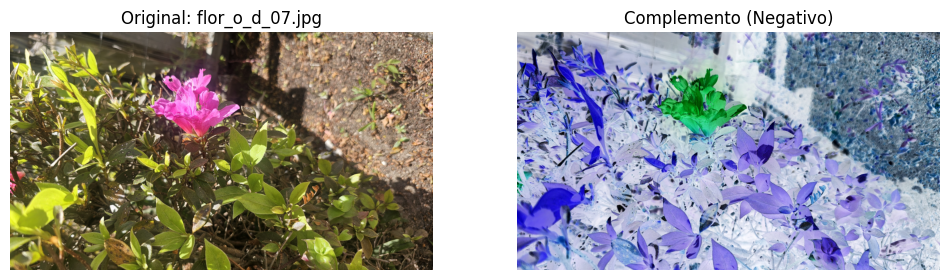


Processamento concluído! Resultados em 'resultados_complemento_cor'


In [47]:
import os
import imageio.v2 as iio
import numpy as np
import matplotlib.pyplot as plt
from skimage import img_as_ubyte
from skimage.color import gray2rgb


class_name_prefix = 'flor'


original_images_dir = '/content/'

# 3. Defina o diretório de saída
output_dir = 'resultados_complemento_cor'
os.makedirs(output_dir, exist_ok=True)

print(f"Buscando imagens com prefixo '{class_name_prefix}' em '{original_images_dir}'...")



try:
    # Lista todos os arquivos na pasta correta
    all_files = [f for f in os.listdir(original_images_dir) if f.lower().endswith(('.jpg', '.png', '.tif', '.jpeg'))]

    # Filtra apenas os arquivos da classe desejada
    flower_images = [f for f in all_files if f.lower().startswith(class_name_prefix)]

    if not flower_images:
        print(f"ERRO: Nenhuma imagem encontrada com o prefixo '{class_name_prefix}' em '{original_images_dir}'.")
        print("Verifique se as imagens originais (ex: 'flor_o_d_07.jpg') estão nessa pasta.")

    for filename in flower_images:
        # Ignora arquivos de resultado de tarefas anteriores
        if filename.startswith(('res_a_', 'res_b_', 'resultado_')):
            continue

        print(f"Processando: {filename}")
        img_path = os.path.join(original_images_dir, filename)

        try:
            # Carrega a imagem
            img_original = iio.imread(img_path)

            # Garante que é RGB (para o complemento de cor)
            if img_original.ndim == 2:
                img_original = gray2rgb(img_original)
            elif img_original.shape[2] == 4:
                img_original = img_original[:, :, :3]

            # Garante que é 8-bit (uint8) para a subtração
            if img_original.dtype != 'uint8':
                img_original = img_as_ubyte(img_original)

            # 4. APLICA A TRANSFORMADA (CÁLCULO DO COMPLEMENTO)
            img_complement = 255 - img_original

            # 5. Salva o resultado
            base_name = os.path.splitext(filename)[0]
            output_path = os.path.join(output_dir, f'complemento_{base_name}.jpg')
            iio.imwrite(output_path, img_complement, quality=95)

            # 6. Exibe a comparação
            fig, axes = plt.subplots(1, 2, figsize=(12, 6))
            axes[0].imshow(img_original)
            axes[0].set_title(f"Original: {filename}")
            axes[0].axis('off')

            axes[1].imshow(img_complement)
            axes[1].set_title(f"Complemento (Negativo)")
            axes[1].axis('off')

            plt.show()

        except Exception as e:
            print(f"  -> ERRO ao processar o arquivo {filename}: {e}. Pulando...")

    print(f"\nProcessamento concluído! Resultados em '{output_dir}'")

except FileNotFoundError:
    print(f"ERRO: O diretório '{original_images_dir}' não foi encontrado.")
except Exception as e:
    print(f"Ocorreu um erro inesperado: {e}")

Introdução objetivo deste trabalho é aplicar a técnica de complemento de cor (também conhecida como negativo de cor) em um conjunto de imagens coloridas. Conforme solicitado, a técnica foi aplicada às imagens da classe "flor" da base de dados do curso.

A transformada de complemento de cor é a extensão direta da transformada de negativo para imagens em tons de cinza. Enquanto em tons de cinza a operação inverte a intensidade (I' = 255 - I), em imagens coloridas (RGB), a operação é aplicada independentemente a cada um dos três canais:

$$R' = 255 - R$$$$G' = 255 - G$$$$B' = 255 - B$$

Isso tem o efeito de mapear cada cor para sua cor complementar no modelo aditivo, e inverter o brilho da imagem (áreas claras ficam escuras e vice-versa).
Metodologia processo foi implementado em um Jupyter Notebook utilizando Python. As bibliotecas imageio e numpy foram usadas para ler as imagens e realizar a transformação.Os arquivos de imagem originais da classe "flor" (ex: flor_o_d_07.jpg) foram lidos.

Foi verificado se as imagens eram RGB 8-bit (uint8).
A operação de negativo (imagem_complemento = 255 - imagem_original) foi aplicada usando numpy, que realiza a subtração elemento a elemento em toda a matriz da imagem.

As imagens resultantes foram salvas na pasta resultados_complemento_cor.

Análise: Como esperado, os resultados demonstram uma inversão completa das cores e do brilho.

Pétalas que eram rosas (ricas no canal R) tornaram-se verde-azuladas (pobres no canal R).

Folhas e caules que eram verdes (ricos no canal G) tornaram-se azul (pobres no canal G).

Áreas de fundo claro brancas tornaram-se pretas ou escuras.

O efeito visual é idêntico ao de um negativo de filme fotográfico colorido, validando a analogia com o negativo em tons de cinza.

Conclusão
A técnica do complemento de cor foi aplicada com sucesso. A transformação (255-R, 255-G, 255-B) inverteu eficazmente os canais de cor, produzindo as cores complementares esperadas e confirmando ser o análogo direto da transformada de negativo em tons de cinza.